Rows: 4208261
Columns: 19

Average CO: 127.62
Maximum CO: 533.33

Average Ethylene: 5.32
Maximum Ethylene: 20.0

Top 5 Sensors for CO
S1     0.640777
S6     0.602067
S5     0.525861
S14    0.505342
S13    0.487300
Name: CO, dtype: float64

Top 5 Sensors for Ethylene
S15    0.665233
S8     0.658543
S7     0.655367
S16    0.618667
S3     0.618532
Name: Ethylene, dtype: float64


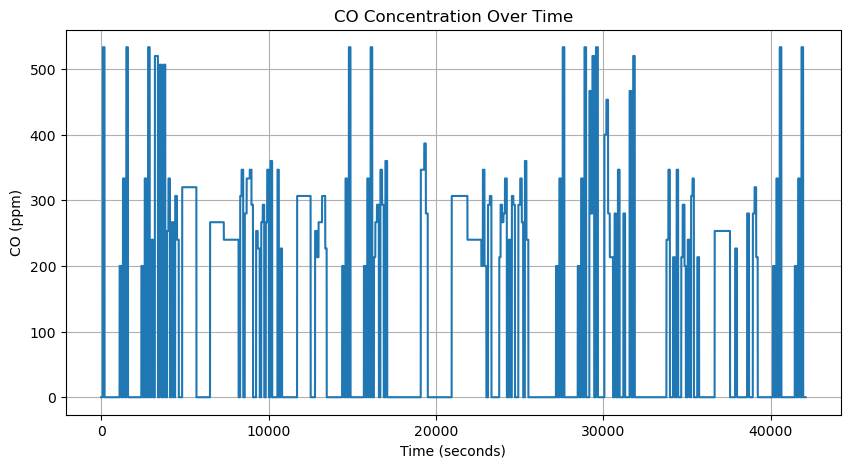

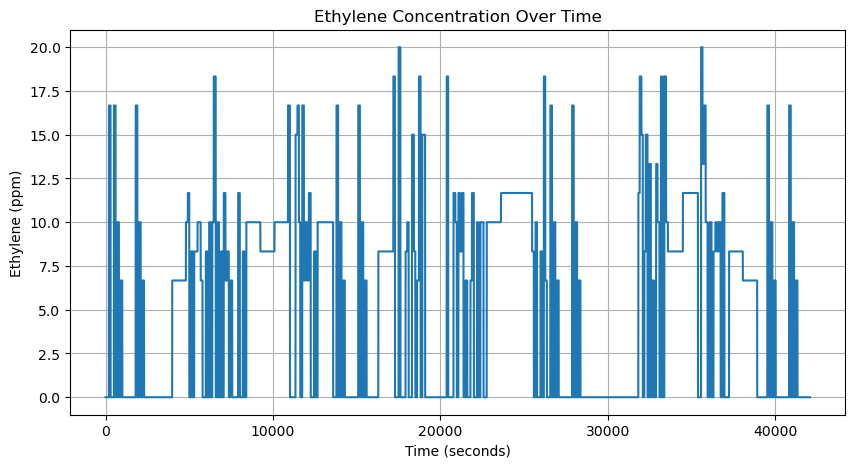

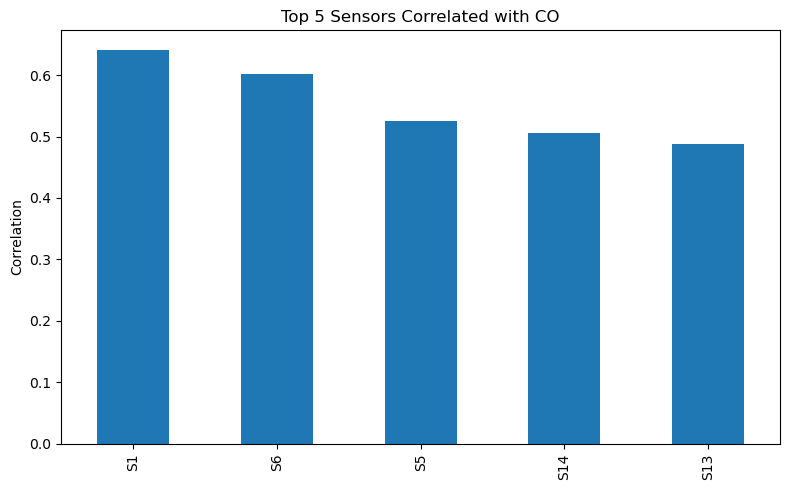

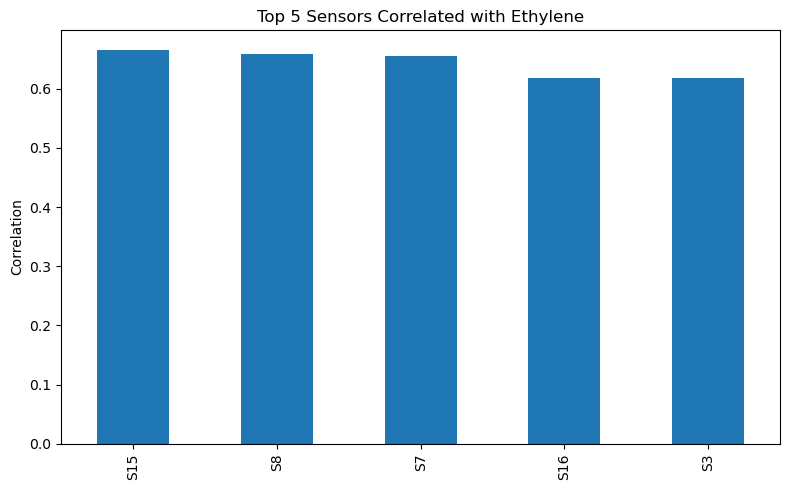

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

cols = [
    "Time","CO","Ethylene",
    "S1","S2","S3","S4","S5","S6","S7","S8",
    "S9","S10","S11","S12","S13","S14","S15","S16"
]

df = pd.read_csv(
    "ethylene_CO.txt",
    sep=r"\s+",
    skiprows=1,
    header=None,
    names=cols,
    engine="python"
)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nAverage CO:", round(df["CO"].mean(),2))
print("Maximum CO:", df["CO"].max())

print("\nAverage Ethylene:", round(df["Ethylene"].mean(),2))
print("Maximum Ethylene:", df["Ethylene"].max())

co_corr = df.corr(numeric_only=True)["CO"].drop("CO").sort_values(ascending=False)
eth_corr = df.corr(numeric_only=True)["Ethylene"].drop("Ethylene").sort_values(ascending=False)

print("\nTop 5 Sensors for CO")
print(co_corr.head())

print("\nTop 5 Sensors for Ethylene")
print(eth_corr.head())

# CO Trend
plt.figure(figsize=(10,5))
plt.plot(df["Time"], df["CO"])
plt.title("CO Concentration Over Time")
plt.xlabel("Time (seconds)")
plt.ylabel("CO (ppm)")
plt.grid(True)
plt.show()

# Ethylene Trend
plt.figure(figsize=(10,5))
plt.plot(df["Time"], df["Ethylene"])
plt.title("Ethylene Concentration Over Time")
plt.xlabel("Time (seconds)")
plt.ylabel("Ethylene (ppm)")
plt.grid(True)
plt.show()

# Top CO Sensors
plt.figure(figsize=(8,5))
co_corr.head(5).plot(kind="bar")
plt.title("Top 5 Sensors Correlated with CO")
plt.ylabel("Correlation")
plt.tight_layout()
plt.show()

# Top Ethylene Sensors
plt.figure(figsize=(8,5))
eth_corr.head(5).plot(kind="bar")
plt.title("Top 5 Sensors Correlated with Ethylene")
plt.ylabel("Correlation")
plt.tight_layout()
plt.show()